In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [3]:
df= pd.read_csv('upi_transactions_2024.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [6]:
df.shape

(250000, 17)

In [7]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [8]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [19]:
df.columns = [
    'transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
    'amount_inr', 'transaction_status', 'sender_age_group',
    'receiver_age_group', 'sender_state', 'sender_bank',
    'receiver_bank', 'device_type', 'network_type',
    'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend'
]

In [21]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_inr', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [22]:
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_inr', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction_id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction_type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount_inr          250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [26]:
df.isnull().sum()

transaction_id        0
timestamp             0
transaction_type      0
merchant_category     0
amount_inr            0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64


### SUCCESS vs FAILED TRANSACTIONS

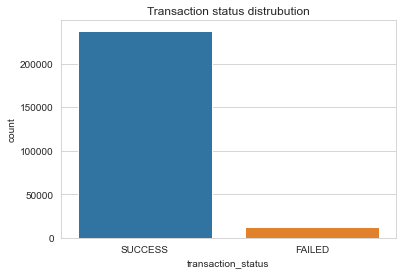

In [32]:
sns.countplot(x="transaction_status",data=df)
plt.title('Transaction status distrubution')
plt.show()


Most transactions are successful, indicating a reliable UPI system with a low failure rate.

### TRANSACTIONS BY HOUR

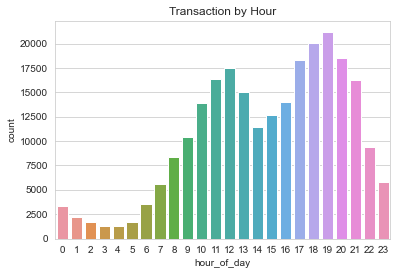

In [39]:
sns.countplot(x='hour_of_day',data=df)
plt.title('Transaction by Hour')
plt.xticks(rotation=1)
plt.show()

Transaction activity is higher during peak hours, indicating increased usage during specific times of the day.

### FRAUD ANALYSIS

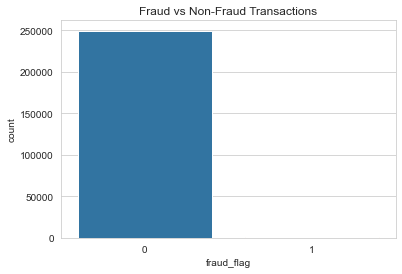

In [42]:
sns.countplot(x='fraud_flag', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

Fraud cases are very rare compared to normal transactions, showing strong security in the system.

### Weekend VS Weekdays Analysis

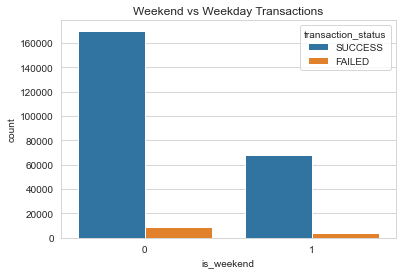

In [43]:
sns.countplot(x='is_weekend', hue='transaction_status', data=df)
plt.title('Weekend vs Weekday Transactions')
plt.show()

Transactions are significantly higher on weekdays with consistently high success rates, and although failures are slightly higher, they are proportional to the higher volume, indicating stable system performance.


#### BANK-WISE TRANSACTIONS

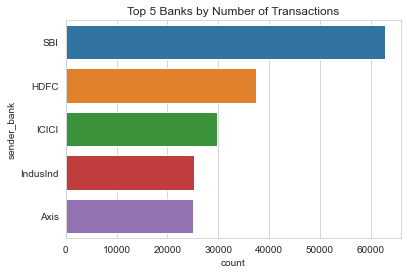

In [47]:
top_banks = df['sender_bank'].value_counts().head(5)

sns.countplot(y='sender_bank', data=df, order=top_banks.index)
plt.title('Top 5 Banks by Number of Transactions')
plt.show()

A few banks dominate the majority of UPI transactions like SBI, indicating higher user trust and adoption for those banks.

### TRANSACTION AMOUNT DISTRIBUTION

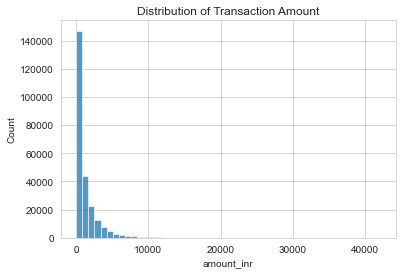

In [13]:
sns.histplot(df['amount_inr'], bins=50)
plt.title('Distribution of Transaction Amount')
plt.show()

Most transactions are of smaller amounts, indicating that UPI is primarily used for everyday low-value payments.

### TRANSACTIONS BY DEVICE TYPE

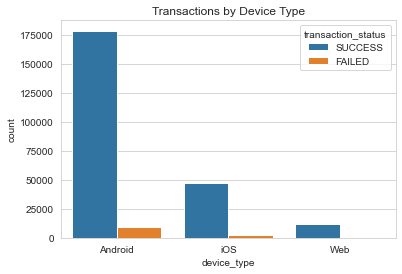

In [16]:
sns.countplot(x='device_type', hue='transaction_status', data=df)
plt.title('Transactions by Device Type')
plt.show()

Most transactions are done through Android devices, showing higher user adoption compared to iOS and web.

## conclusion

#### The analysis of UPI transactions highlights a strong adoption of digital payments with a high success rate, indicating system reliability. Most transactions are low-value and are primarily conducted through mobile devices, especially Android, showing everyday usage patterns. Transaction activity is higher during specific peak hours and weekdays, reflecting user behavior trends. Certain banks and states dominate transaction volume, indicating higher regional adoption and trust. Fraudulent transactions are minimal but present, emphasizing the importance of continuous monitoring. Overall, the UPI ecosystem is efficient, secure, and widely adopted.